Name: Prashna Shrestha

st id: 2408642

week 4 worksheet

In [1]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


In [2]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [3]:
import zipfile
import os

# Path to the zip file and extraction directory
zip_file_path = '/content/drive/MyDrive/Ai and machine learning/week 4/Copy of Copy of devnagari digit.zip'
extract_dir = 'devnagari_digit_extracted'

# Create the extraction directory if it doesn't exist
if not os.path.exists(extract_dir):
    os.makedirs(extract_dir)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Contents of '{zip_file_path}' extracted to '{extract_dir}' successfully.")

# Verify contents (optional)
print('\nContents of the extracted folder:')
for root, dirs, files in os.walk(extract_dir):
    for name in files:
        print(os.path.join(root, name))

Contents of '/content/drive/MyDrive/Ai and machine learning/week 4/Copy of Copy of devnagari digit.zip' extracted to 'devnagari_digit_extracted' successfully.

Contents of the extracted folder:
devnagari_digit_extracted/DevanagariHandwrittenDigitDataset/Test/digit_4/41025.png
devnagari_digit_extracted/DevanagariHandwrittenDigitDataset/Test/digit_4/67391.png
devnagari_digit_extracted/DevanagariHandwrittenDigitDataset/Test/digit_4/67310.png
devnagari_digit_extracted/DevanagariHandwrittenDigitDataset/Test/digit_4/77528.png
devnagari_digit_extracted/DevanagariHandwrittenDigitDataset/Test/digit_4/92503.png
devnagari_digit_extracted/DevanagariHandwrittenDigitDataset/Test/digit_4/67339.png
devnagari_digit_extracted/DevanagariHandwrittenDigitDataset/Test/digit_4/40916.png
devnagari_digit_extracted/DevanagariHandwrittenDigitDataset/Test/digit_4/89758.png
devnagari_digit_extracted/DevanagariHandwrittenDigitDataset/Test/digit_4/69118.png
devnagari_digit_extracted/DevanagariHandwrittenDigitDataset

In [4]:
for root, dirs, files in os.walk("devnagari_digit_extracted"):
    print(root)

devnagari_digit_extracted
devnagari_digit_extracted/DevanagariHandwrittenDigitDataset
devnagari_digit_extracted/DevanagariHandwrittenDigitDataset/Test
devnagari_digit_extracted/DevanagariHandwrittenDigitDataset/Test/digit_4
devnagari_digit_extracted/DevanagariHandwrittenDigitDataset/Test/digit_1
devnagari_digit_extracted/DevanagariHandwrittenDigitDataset/Test/digit_9
devnagari_digit_extracted/DevanagariHandwrittenDigitDataset/Test/digit_2
devnagari_digit_extracted/DevanagariHandwrittenDigitDataset/Test/digit_3
devnagari_digit_extracted/DevanagariHandwrittenDigitDataset/Test/digit_8
devnagari_digit_extracted/DevanagariHandwrittenDigitDataset/Test/digit_0
devnagari_digit_extracted/DevanagariHandwrittenDigitDataset/Test/digit_6
devnagari_digit_extracted/DevanagariHandwrittenDigitDataset/Test/digit_5
devnagari_digit_extracted/DevanagariHandwrittenDigitDataset/Test/digit_7
devnagari_digit_extracted/DevanagariHandwrittenDigitDataset/Train
devnagari_digit_extracted/DevanagariHandwrittenDigitD

Task 1

Training set: (17000, 28, 28), Labels: (17000,)
Test set:     (3000, 28, 28),  Labels: (3000,)


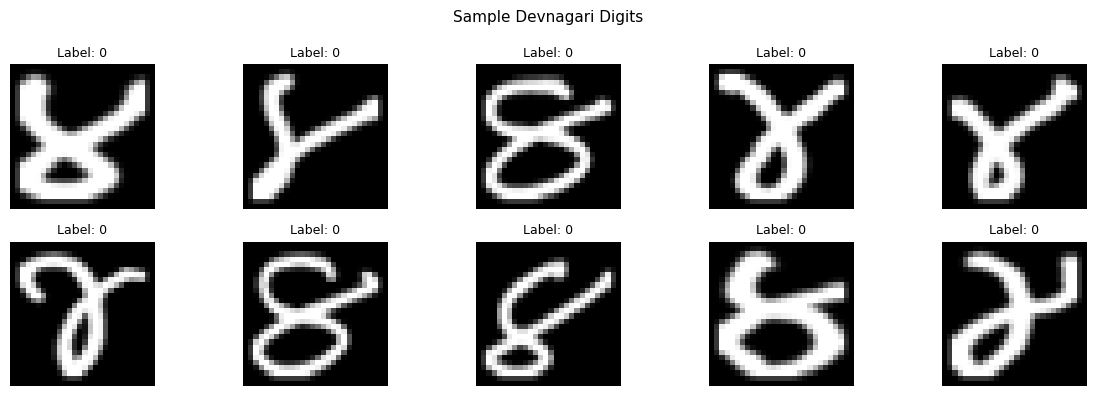

In [5]:
def load_data(data_dir):
    images = []
    labels = []

    for label in os.listdir(data_dir):
        label_path = os.path.join(data_dir, label)

        if not os.path.isdir(label_path):
            continue

        # Extract number from folder name like "digit_3" → 3
        digit = int(label.split('_')[1])

        for file in os.listdir(label_path):
            img_path = os.path.join(label_path, file)

            try:
                img = Image.open(img_path).convert('L')
                img = img.resize((28, 28))
                img = np.array(img) / 255.0

                images.append(img)
                labels.append(digit)
            except:
                pass

    return np.array(images), np.array(labels)

base_path = "devnagari_digit_extracted/DevanagariHandwrittenDigitDataset"
X_train, y_train = load_data(os.path.join(base_path, "Train"))
X_test, y_test = load_data(os.path.join(base_path, "Test"))



In [6]:
# Reshape for FCN (flatten later)
X_train = X_train.reshape(-1, 28, 28)
X_test = X_test.reshape(-1, 28, 28)

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print(f"Training set: {X_train.shape}, Labels: {y_train.shape}")
print(f"Test set:     {X_test.shape},  Labels: {y_test.shape}")

# Visualise sample images
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}", fontsize=9)
    plt.axis('off')
plt.suptitle("Sample Devnagari Digits", fontsize=11)
plt.tight_layout()
plt.show()

Task 2

In [7]:
model = Sequential()

# Flatten input
model.add(Flatten(input_shape=(28, 28)))

# Hidden layers
model.add(Dense(64, activation='sigmoid'))
model.add(Dense(128, activation='sigmoid'))
model.add(Dense(256, activation='sigmoid'))

# Output layer
model.add(Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

Task 3

In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Task 4

In [9]:
checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True, monitor='val_loss')
early_stop = EarlyStopping(patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/20
 99/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2553 - loss: 2.0132

107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.4724 - loss: 1.6409 - val_accuracy: 0.0000e+00 - val_loss: 6.9730
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8618 - loss: 0.4612 - val_accuracy: 0.0000e+00 - val_loss: 8.3513
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9281 - loss: 0.2555 - val_accuracy: 0.0000e+00 - val_loss: 9.1908
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9518 - loss: 0.1691 - val_accuracy: 0.0000e+00 - val_loss: 9.6495
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9640 - loss: 0.1268 - val_accuracy: 0.0000e+00 - val_loss: 10.0380
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9743 - loss: 0.0959 - val_accuracy: 0.0000e+00 - val_loss: 10.5228


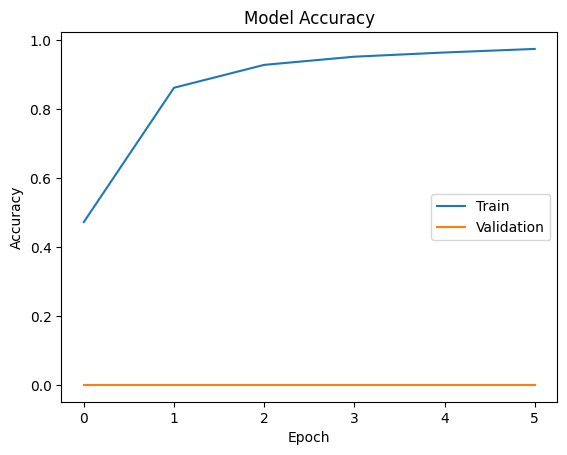

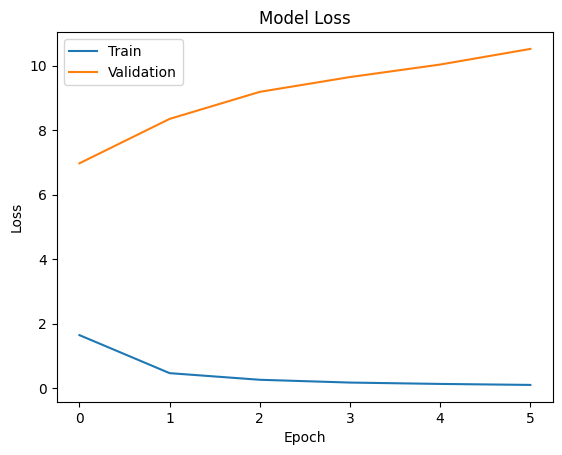

In [10]:
# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

Task 5

In [11]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6743 - loss: 1.9829
Test Accuracy: 0.6743333339691162
Test Loss: 1.9828740358352661


Task 6

In [12]:
# Save
model.save("devnagari_fcn.h5")

# Load
loaded_model = load_model("devnagari_fcn.h5")

# Re-evaluate
loss, accuracy = loaded_model.evaluate(X_test, y_test)
print("Loaded Model Accuracy:", accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6743 - loss: 1.9829
Loaded Model Accuracy: 0.6743333339691162


Task 7

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


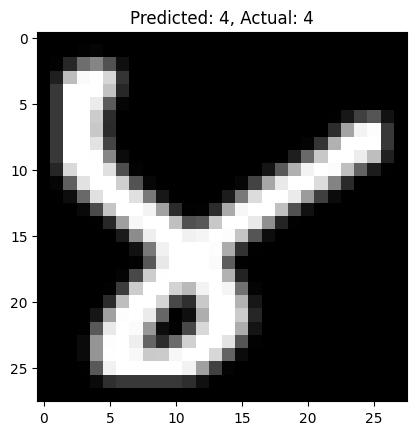

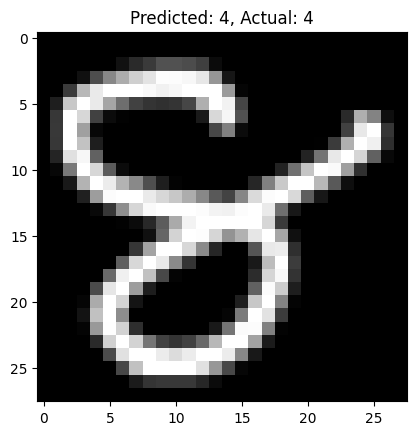

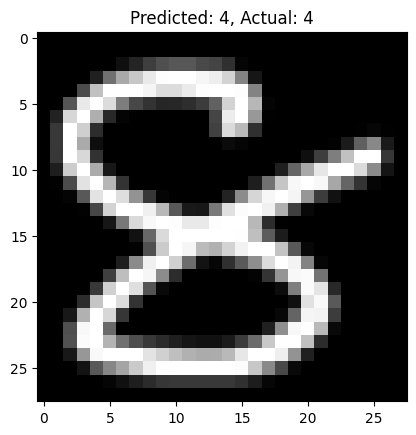

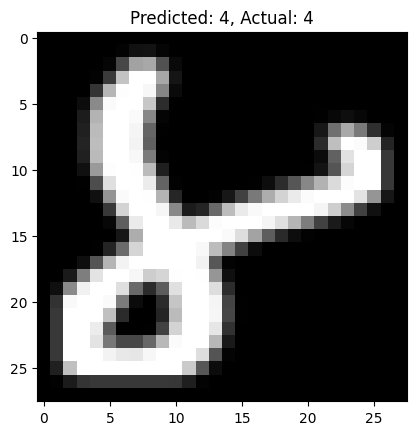

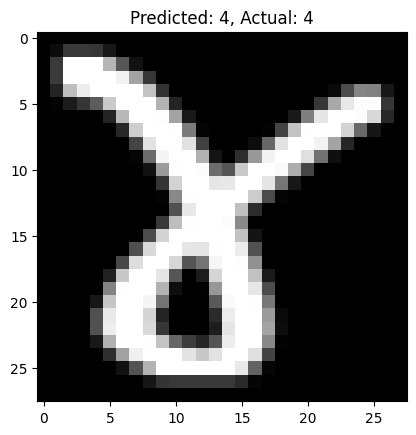

In [13]:
predictions = loaded_model.predict(X_test)

# Convert probabilities → labels
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

# Show some predictions
for i in range(5):
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f"Predicted: {predicted_labels[i]}, Actual: {true_labels[i]}")
    plt.show()